# makes HBV for testing Aral Sea Balance


In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

from ewatercycle_leakybucket.model import LeakyBucket

## Load Data

In [2]:
# The name of the shapefile
shape_file_name = "Chatly_GRDC"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "2000-12-31T00:00:00Z"

forcing_path_ERA5 = (
    Path.home()
    / "MSc_AralSea"
    / "book"
    / "thesis_projects"
    / "MSc"
    / "2025_Q1_AndreVanDerVeen_CEG"
    / "work_in_progress"
    / "Test_Aral"
    / "forcing_Chatly_GRDC_HBV_5000"
    / shape_file_name
    / "ERA5"
    / "own_shapefile"
)
# forcing_path_ERA5 = (
#     Path.cwd()
#     / "AralSea_Basin"
#     / "forcing_Kerki"
#     / shape_file_name
#     / "ERA5"
#     / "own_shapefile"
# )


# The path save directory of the ERA5 data
#forcing_path_ERA5 = Path.home() / "projects/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Aral_Test/forcing" / shape_file_name / "ERA5" / "own_shapefile"
#forcing_path_ERA5.mkdir(exist_ok=True)
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script" 
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)


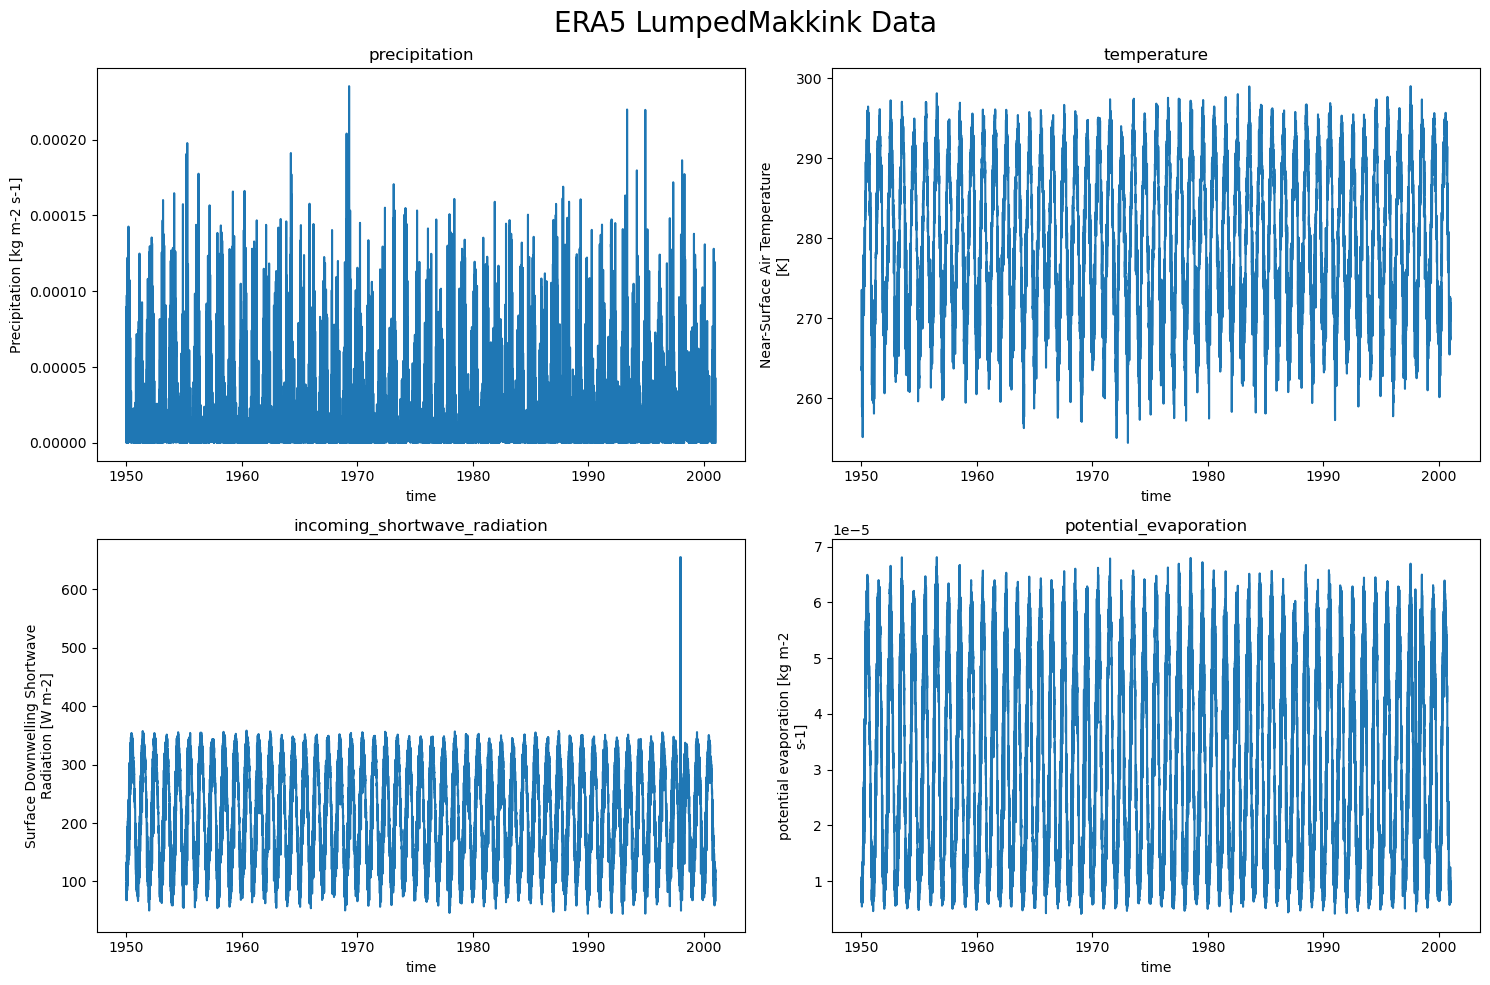

In [3]:
ERA5_data = {'precipitation pr': xr.open_dataset(ERA5_forcing['pr']),
             'temperature tas': xr.open_dataset(ERA5_forcing['tas']),
             'incoming_shortwave_radiation rsds': xr.open_dataset(ERA5_forcing['rsds']),
             'potential_evaporation evspsblpot': xr.open_dataset(ERA5_forcing['evspsblpot'])

             
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2,2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

## HBV

In [4]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)


In [5]:
# parameter_set =  [
#     15.085,  # Imax
#     0.837,  # Ce
#     76.373, # Sumax
#     1.112,  # Beta
#     0.245,  # Pmax
#     7.801,  # Tlag
#     0.096,  # Kf
#     0.003,  # Ks
#     0.226   # FM
# ]

parameter_set=[2.10167744e+01, 7.12767946e-01, 3.98488875e+02, 1.02387591e+00,
 6.70083627e-02, 4.02777470e+01, 1.46319728e-02, 4.42609793e-03,
 1.63752793e-01]

initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

In [6]:
config_file, _ = model.setup(parameters=parameter_set, initial_storage=initial_conditions)

In [7]:
model.initialize(config_file)

In [8]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [9]:
# Finalize model (shuts down container, frees memory)
model.finalize()

In [10]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

<Axes: title={'center': 'HBV Modelled Discharge GRDC Station Chatly'}, xlabel='Time', ylabel='Discharge (m3/s)'>

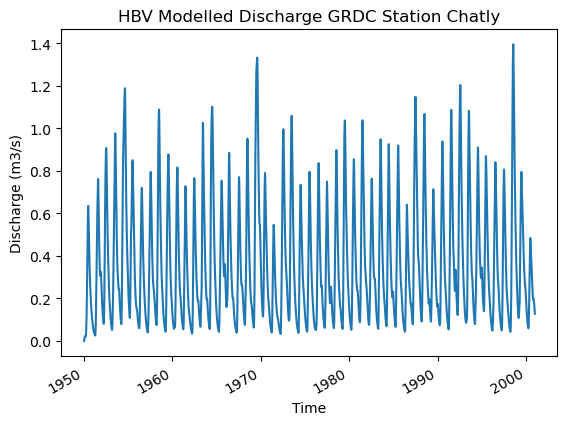

In [11]:
model_output.plot(title="HBV Modelled Discharge GRDC Station Chatly", ylabel="Discharge (m3/s)", xlabel="Time")

Text(0, 0.5, 'Discharge (mm/d)')

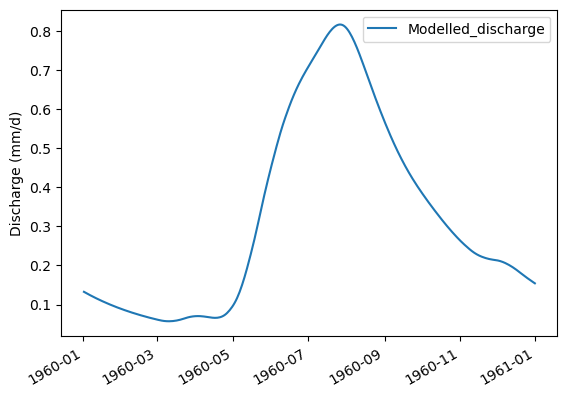

In [12]:
#model_output.plot()

# Filter only year 1997
data_1997 = model_output[model_output.index.year == 1960]

# Plot
data_1997.plot()
#ds_forcing["Q"].plot(label="Observed discharge")
plt.legend()
plt.ylabel("Discharge (mm/d)")

In [13]:
# We want to also be able to use the output of this model run in different analyses. Therefore we save it as a NetCDF file
xr_model_output = model_output.to_xarray()

xr_model_output.attrs['units'] = 'mm/d'

# Save the xarray Dataset to a NetCDF file
#xr_model_output.to_netcdf(Path.cwd()/'Aral_AmuDarya_Kerki.nc')

In [14]:
#xr_model_output

In [15]:
#model_output

In [16]:

model_output.to_csv("HBV_GRDC_Chatly_5000_VE_max.csv", index=True)